In [1]:
import torch
import numpy as np
import torch.nn as nn
from pathlib import Path
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler

import sys
sys.path.append('..')
import plot_settings
plot_settings.apply()

In [2]:
# -----------------------------
# 0) Load I/V data
# -----------------------------
BASE_DIR = Path.cwd()
I = np.load(BASE_DIR.parent / 'NO/data_NO/I.npz')['arr_0']   # [N,1,T]
V = np.load(BASE_DIR.parent / 'NO/data_NO/V.npz')['arr_0']   # [N,1,T]

I = I.reshape(I.shape[0], -1)  # [N, T]
V = V.reshape(V.shape[0], -1)  # [N, T]
N, T = I.shape

test_size = 0.1
split = int(test_size * N)

I_test = I[:split]
V_test = V[:split]
I_train = I[split:]
V_train = V[split:]

In [3]:
# -----------------------------
# 1) Scaling
# -----------------------------
# For physics/ODE models you usually want GLOBAL scaling, not a separate mean/std per time index.
scaler_I = StandardScaler()
scaler_V = StandardScaler()

I_train_s = scaler_I.fit_transform(I_train.reshape(-1, 1)).reshape(-1, T)  # global
V_train_s = scaler_V.fit_transform(V_train.reshape(-1, 1)).reshape(-1, T)  # global
I_test_s  = scaler_I.transform(I_test.reshape(-1, 1)).reshape(-1, T)
V_test_s  = scaler_V.transform(V_test.reshape(-1, 1)).reshape(-1, T)

# To keep the ECM solver in PHYSICAL UNITS we will unscale inside the forward, using these constants as torch scalars:
I_mean_t = torch.tensor(float(scaler_I.mean_[0]), dtype=torch.float32)
I_std_t  = torch.tensor(float(scaler_I.scale_[0]), dtype=torch.float32)
V_mean_t = torch.tensor(float(scaler_V.mean_[0]), dtype=torch.float32)
V_std_t  = torch.tensor(float(scaler_V.scale_[0]), dtype=torch.float32)

# To sequences [N, T, 1]
I_train_s = I_train_s[..., None].astype(np.float32)
V_train_s = V_train_s[..., None].astype(np.float32)
I_test_s  = I_test_s[..., None].astype(np.float32)
V_test_s  = V_test_s[..., None].astype(np.float32)

train_dataset = TensorDataset(torch.from_numpy(I_train_s), torch.from_numpy(V_train_s))
loader = DataLoader(train_dataset, batch_size=32, shuffle=True, drop_last=True)


In [4]:
# -----------------------------
# 2) Parameter network: sequence -> parameters
# -----------------------------

class ECMParamNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.gru = nn.GRU(
            input_size=1,
            hidden_size=128,
            num_layers=1,
            batch_first=True
        )
        self.head = nn.Sequential(
            nn.Linear(in_features=128, out_features=64),
            nn.ReLU(),
            nn.Linear(64, 3)  # output R0, R1, C1
        )

    def forward(self, I_seq_scaled):
        # I_seq_scaled: [B, T, 1] (scaled)
        _, h_last = self.gru(I_seq_scaled)          # h_last: [1, B, H]
        h_last = h_last.squeeze(0)                  # [B, H]
        raw = self.head(h_last)                     # [B, out_dim]

        # Positivity constraints
        # R0 = self.softplus(raw[:, 0]) + 1e-6
        # R1 = self.softplus(raw[:, 1]) + 1e-6
        # C1 = self.softplus(raw[:, 2]) + 1e-6
        # R0 = raw[:, 0]
        # R1 = raw[:, 1]
        # C1 = raw[:, 2]

        # Constraints via sigmoid to keep parameters in a reasonable range
        R0 = 0.005 + 0.5 * torch.sigmoid(raw[:,0])
        R1 = 0.005 + 0.5 * torch.sigmoid(raw[:,1])
        C1 = 500  + 5000 * torch.sigmoid(raw[:,2])
        return R0, R1, C1

In [5]:
# -----------------------------
# 3) ECM solver as a differentiable PyTorch module
# -----------------------------

def voc_poly_torch(z, coeffs):
    '''
    Evaluate polynomial Voc(z) with Horner's method.
    z: [B, T] in [0,1]
    coeffs: [P] highest power first
    returns Voc: [B, T]
    '''
    y = torch.zeros_like(z)
    for c in coeffs.to(z.device):
        y = y * z + c
    return y

def ecm_forward(I_seq_scaled, params, dt, Q, voc_coeffs):
    ''' 
    U1_{k+1} = U1_k + dt * ( -U1_k/(R1*C1) + I_k/C1 )
    z_{k+1}  = z_k  - dt * I_k / Q
    V_k      = Voc(z_k) - R0*I_k - U1_k
    '''

    R0, R1, C1 = params

    # Unscale current to physical units
    I_s = I_seq_scaled.squeeze(-1)              # [B, T]
    I_phys = I_s * I_std_t + I_mean_t          # [B, T]

    B, T = I_phys.shape

    # Initial states
    U1 = torch.zeros(B, dtype=torch.float32)   # [B]
    z = torch.ones(B)  # [B]

    V_out = []
    U1_traj = []
    z_traj = []

    for k in range(T):
        Ik = I_phys[:, k]  # [B]

        # Save states before update
        U1_traj.append(U1)
        z_traj.append(z)

        # Voltage at current state
        Voc = voc_poly_torch(z.view(B, 1), voc_coeffs).view(B)
        Vk = Voc - R0 * Ik - U1
        V_out.append(Vk)

        # No update after last sample
        if k == T - 1:
            break

        # Explicit Euler updates
        dU1 = -U1 / (R1 * C1) + Ik / C1
        dz  = -Ik / Q

        U1 = U1 + dt * dU1
        z  = z  + dt * dz

        # Keep SOC reasonable
        z = torch.clamp(z, 0.0, 1.0)

    V_phys = torch.stack(V_out, dim=1)      # [B, T]
    U1_traj = torch.stack(U1_traj, dim=1)   # [B, T]
    z_traj  = torch.stack(z_traj, dim=1)    # [B, T]

    # Scale voltage back to normalized space
    V_scaled = (V_phys - V_mean_t) / V_std_t
    V_scaled = V_scaled.unsqueeze(-1)

    return V_scaled, V_phys, {"U1": U1_traj, "z": z_traj, "I": I_phys}

In [6]:
# -----------------------------
# 4) Training loop
# -----------------------------

DT = 1.0     # seconds
Q_AS = 2448.0  # capacity in A*s (adjust)
VOC_COEFFS = torch.tensor([-1.14891765e+03,  6.44025200e+03, -1.55588683e+04,  2.11860429e+04,
 -1.78633530e+04,  9.66208361e+03, -3.36907238e+03,  7.44974570e+02,
 -1.00279728e+02,  7.54862624e+00,  3.44092384e+00], dtype=torch.float32)

model = ECMParamNet()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
mse = nn.MSELoss()

def training(epochs=50):
    history = {"loss": [], "R0": [], "R1": [], "C1": []}
    for ep in range(epochs):
        model.train()
        last = None

        for I_batch, V_batch in loader:
            # predict parameters
            R0, R1, C1 = model(I_batch)

            # forward ECM
            V_hat, _, _ = ecm_forward(I_batch, (R0, R1, C1),
                                    dt=DT, Q=Q_AS, voc_coeffs=VOC_COEFFS)

            loss = mse(V_hat, V_batch)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            last = float(loss.item())

        history["loss"].append(last)
        history["R0"].append(float(R0.mean().item()))
        history["R1"].append(float(R1.mean().item()))
        history["C1"].append(float(C1.mean().item()))

        print(f"Epoch {ep+1:3d} | loss {last:.6f} | "
              f"R0 {history['R0'][-1]:.5g} | R1 {history['R1'][-1]:.5g} | C1 {history['C1'][-1]:.5g}")

    return history

In [7]:
history = training(epochs=20)

Epoch   1 | loss 0.464699 | R0 0.26034 | R1 0.26122 | C1 3011.5
Epoch   2 | loss 0.447113 | R0 0.25312 | R1 0.27364 | C1 2841.6
Epoch   3 | loss 0.346237 | R0 0.24056 | R1 0.30859 | C1 2402.8
Epoch   4 | loss 0.069605 | R0 0.19808 | R1 0.42867 | C1 1070.7
Epoch   5 | loss 0.039935 | R0 0.12537 | R1 0.48187 | C1 637
Epoch   6 | loss 0.051683 | R0 0.13703 | R1 0.49287 | C1 603.59
Epoch   7 | loss 0.032722 | R0 0.13318 | R1 0.49411 | C1 651.88
Epoch   8 | loss 0.017577 | R0 0.14908 | R1 0.49362 | C1 779.4
Epoch   9 | loss 0.017281 | R0 0.16583 | R1 0.49338 | C1 936.21
Epoch  10 | loss 0.021160 | R0 0.15975 | R1 0.49439 | C1 950.25
Epoch  11 | loss 0.015787 | R0 0.15924 | R1 0.49628 | C1 849.2
Epoch  12 | loss 0.016220 | R0 0.1476 | R1 0.49735 | C1 806.47
Epoch  13 | loss 0.014329 | R0 0.15476 | R1 0.4981 | C1 818.2
Epoch  14 | loss 0.015938 | R0 0.15328 | R1 0.49848 | C1 861.68
Epoch  15 | loss 0.018545 | R0 0.15796 | R1 0.499 | C1 881.73
Epoch  16 | loss 0.015525 | R0 0.15765 | R1 0.4995

Predicted params:
R0: 0.157, R1: 0.501, C1: 870.0


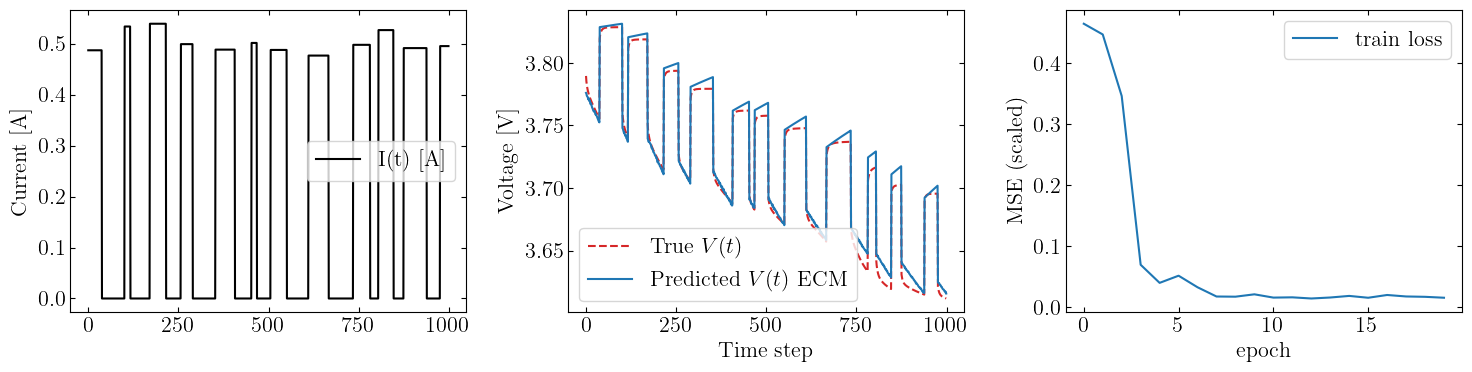

In [8]:
# -----------------------------
# 5) Test + plot
# -----------------------------
model.eval()
idx = 3

I_seq_s = torch.from_numpy(I_test_s[idx:idx+1])  # [1, T, 1]
V_seq_s = torch.from_numpy(V_test_s[idx:idx+1])  # [1, T, 1]

with torch.no_grad():
    R0, R1, C1 = model(I_seq_s)
    V_hat, V_hat_phys, states = ecm_forward(I_seq_s, (R0, R1, C1),
                                        dt=DT, Q=Q_AS, voc_coeffs=VOC_COEFFS)

# back to physical for plotting
I_phys = scaler_I.inverse_transform(I_seq_s.squeeze(-1).numpy().reshape(-1, 1)).reshape(1, T)
V_phys = scaler_V.inverse_transform(V_seq_s.squeeze(-1).numpy().reshape(-1, 1)).reshape(1, T)
Vhat_phys_np = V_hat_phys.numpy()

print("Predicted params:")
print(f'R0: {R0.item():.3f}, R1: {R1.item():.3f}, C1: {C1.item():.1f}')

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 4))
ax1.plot(I_phys.ravel(), color="black", label="I(t) [A]")
ax2.plot(V_phys.ravel(), color="tab:red", linestyle="dashed", label="True $V(t)$")
ax2.plot(Vhat_phys_np.ravel(), color="tab:blue", label="Predicted $V(t)$ ECM")
ax2.legend()
ax1.legend()
ax2.set_xlabel("Time step")
ax1.set_ylabel("Current [A]")
ax2.set_ylabel("Voltage [V]")

ax3.plot(history["loss"], label="train loss")
ax3.set_xlabel("epoch")
ax3.set_ylabel("MSE (scaled)")
ax3.legend()
plt.tight_layout()
# plt.savefig('figs/2_JN_PENN_ECM.pdf')